In [1]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import zarr

from srm.downscaling_utils import interpolate_fine_to_coarse_grid

# Get data

In [2]:
path_output = "s3://carbonplan-scratch/srm/outputs/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/"
path_figs = "/scratch/synced/qa_plots/"
var = "tasmax"
scenario = "ssp245"
ens = "007"

In [3]:
storage = icechunk.s3_storage(
    bucket="carbonplan-scratch",
    prefix="srm/outputs/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session("main")
root = zarr.open_group(session.store, mode="r")
print(root.tree())

{'main'}
/
├── debiased_coarse
│   ├── historical
│   │   ├── dtr
│   │   │   └── 001
│   │   │       ├── dtr (13514, 14, 14) float32
│   │   │       ├── lat (14,) float64
│   │   │       ├── lon (14,) float64
│   │   │       └── time (13514,) int64
│   │   ├── tas
│   │   │   └── r2i1p1f1
│   │   │       ├── lat (14,) float64
│   │   │       ├── lon (14,) float64
│   │   │       ├── tas (13514, 14, 14) float32
│   │   │       └── time (13514,) int64
│   │   ├── tasmax
│   │   │   └── 001
│   │   │       ├── lat (14,) float64
│   │   │       ├── lon (14,) float64
│   │   │       ├── tasmax (13514, 14, 14) float32
│   │   │       └── time (13514,) int64
│   │   └── tasmin
│   │       └── 001
│   │           ├── lat (14,) float64
│   │           ├── lon (14,) float64
│   │           ├── tasmin (13514, 14, 14) float32
│   │           └── time (13514,) int64
│   └── ssp245
│       ├── dtr
│       │   └── 007
│       │       ├── dtr (31046, 14, 14) float32
│       │       ├── lat (14,) floa

In [4]:
def open_icechunk_group(path, group):
    bucket, prefix = path.replace("s3://", "").rstrip("/").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")
    return xr.open_dataset(session.store, engine="zarr", group=group, chunks={})


coarse_debiased = open_icechunk_group(
    path_output, "debiased_coarse/" + scenario + "/" + var + "/" + ens
)
debiased_downscaled = open_icechunk_group(path_output, scenario + "/" + var + "/" + ens)

# Re-coarsen debiased, downscaled data
Ideally, the spatial disaggregation step should spread out data in the coarse grid cell, but not actually change the coarse average. So if we recoarsen the downscaled, debiased data, ideally it would be the same as the debiased, coarse data, and this should be true at every point in time. However, the Thrasher implementation of BCSD does not guarantee that this is the case mathematically, so we need to evaluate how much the downscaling changes the answer.

In [15]:
debiased_downscaled_coarsened = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=debiased_downscaled[var], da_coarse_grid=coarse_debiased[var]
)

# Make figures to evaluate how downscaling changes the answer

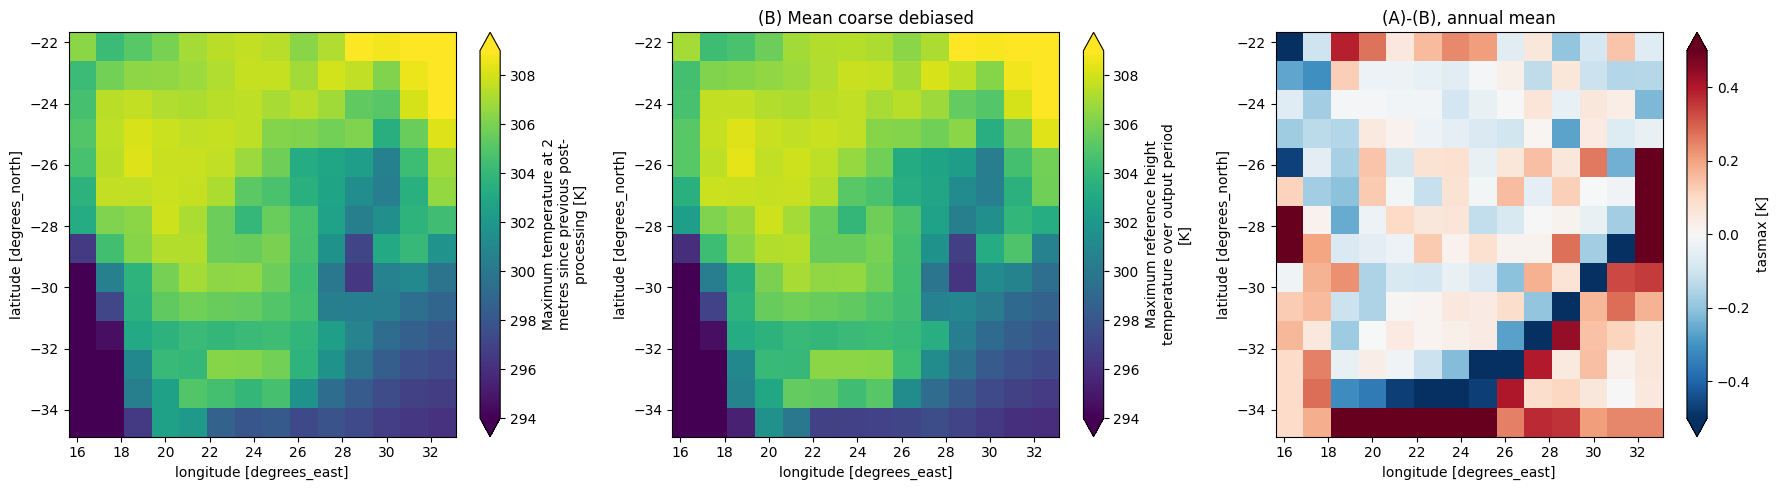

In [24]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.title("(A) Mean re-coarsened debiased, downscaled")
debiased_downscaled_coarsened.mean(dim="time").plot(vmax=309, vmin=294)
plt.subplot(1, 3, 2)
coarse_debiased[var].mean(dim="time").plot(vmax=309, vmin=294)
plt.title("(B) Mean coarse debiased")
plt.subplot(1, 3, 3)
(debiased_downscaled_coarsened.mean(dim="time") - coarse_debiased[var].mean(dim="time")).plot(
    vmax=0.5, vmin=-0.5, cmap=plt.cm.RdBu_r
)
plt.title("(A)-(B), annual mean")
plt.tight_layout()
plt.savefig(path_figs + "disagg_tests_" + var + "_" + scenario + "_" + ens + "_mean_comparison.png")

### How much does the answer change at a given point?

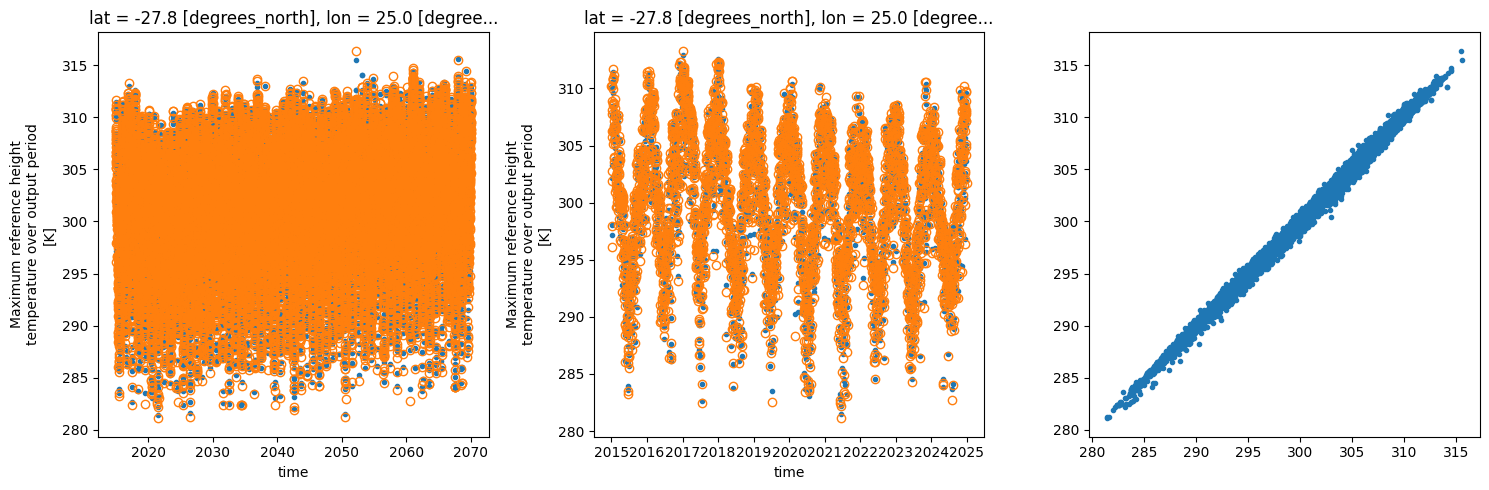

In [19]:
ix = 7
iy = 7
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
debiased_downscaled_coarsened[:, ix, iy].where(
    debiased_downscaled_coarsened["time.year"] < 2070
).plot(marker=".", linestyle="none")
coarse_debiased[var][:, ix, iy].where(debiased_downscaled_coarsened["time.year"] < 2070).plot(
    marker="o", fillstyle="none", linestyle="none"
)
plt.subplot(1, 3, 2)
debiased_downscaled_coarsened[:, ix, iy].where(
    debiased_downscaled_coarsened["time.year"] < 2025
).plot(marker=".", linestyle="none")
coarse_debiased[var][:, ix, iy].where(debiased_downscaled_coarsened["time.year"] < 2025).plot(
    marker="o", fillstyle="none", linestyle="none"
)
plt.subplot(1, 3, 3)
plt.plot(
    debiased_downscaled_coarsened[:, ix, iy].where(
        debiased_downscaled_coarsened["time.year"] < 2070
    ),
    coarse_debiased[var][:, ix, iy].where(debiased_downscaled_coarsened["time.year"] < 2070),
    ".",
)
plt.tight_layout()

## How much does the answer change at all points?

In [20]:
mask = debiased_downscaled_coarsened["time.year"] < 2070

x = debiased_downscaled_coarsened.where(mask)  # (time, lat, lon)
y = coarse_debiased[var].where(mask)  # (time, lat, lon)

# Align on time so positional pairing can't silently drift
x, y = xr.align(x, y, join="inner")

# Only count cells/times where BOTH are finite, so every metric uses the same n
good = x.notnull() & y.notnull()
x = x.where(good)
y = y.where(good)

resid = y - x  # deviation from 1:1 line

n = good.sum("time")
bias = resid.mean("time")
mae = np.abs(resid).mean("time")
rmse = np.sqrt((resid**2).mean("time"))
max_dev = np.abs(resid).max("time")
std_resid = resid.std("time")
rmse_perp = rmse / np.sqrt(2)

# R² vs 1:1 (Nash–Sutcliffe): 1 = perfect, can go negative
ss_res = (resid**2).sum("time")
ss_tot = ((y - y.mean("time")) ** 2).sum("time")
r2_oneone = 1 - ss_res / ss_tot

# Pearson r per cell (shape agreement) for contrast
xm, ym = x - x.mean("time"), y - y.mean("time")
pearson = (xm * ym).sum("time") / np.sqrt((xm**2).sum("time") * (ym**2).sum("time"))

metrics = xr.Dataset(
    {
        "n": n,
        "bias": bias,
        "mae": mae,
        "rmse": rmse,
        "rmse_perp": rmse_perp,
        "max_dev": max_dev,
        "std_resid": std_resid,
        "r2_oneone": r2_oneone,
        "pearson": pearson,
    }
)
print(metrics)

<xarray.Dataset> Size: 9kB
Dimensions:    (lat: 14, lon: 14)
Coordinates:
  * lat        (lat) float64 112B -34.4 -33.46 -32.51 ... -24.03 -23.09 -22.15
  * lon        (lon) float64 112B 16.25 17.5 18.75 20.0 ... 30.0 31.25 32.5
Data variables:
    n          (lat, lon) int64 2kB dask.array<chunksize=(8, 14), meta=np.ndarray>
    bias       (lat, lon) float32 784B dask.array<chunksize=(8, 14), meta=np.ndarray>
    mae        (lat, lon) float32 784B dask.array<chunksize=(8, 14), meta=np.ndarray>
    rmse       (lat, lon) float32 784B dask.array<chunksize=(8, 14), meta=np.ndarray>
    rmse_perp  (lat, lon) float64 2kB dask.array<chunksize=(8, 14), meta=np.ndarray>
    max_dev    (lat, lon) float32 784B dask.array<chunksize=(8, 14), meta=np.ndarray>
    std_resid  (lat, lon) float32 784B dask.array<chunksize=(8, 14), meta=np.ndarray>
    r2_oneone  (lat, lon) float32 784B dask.array<chunksize=(8, 14), meta=np.ndarray>
    pearson    (lat, lon) float32 784B dask.array<chunksize=(8, 14), me

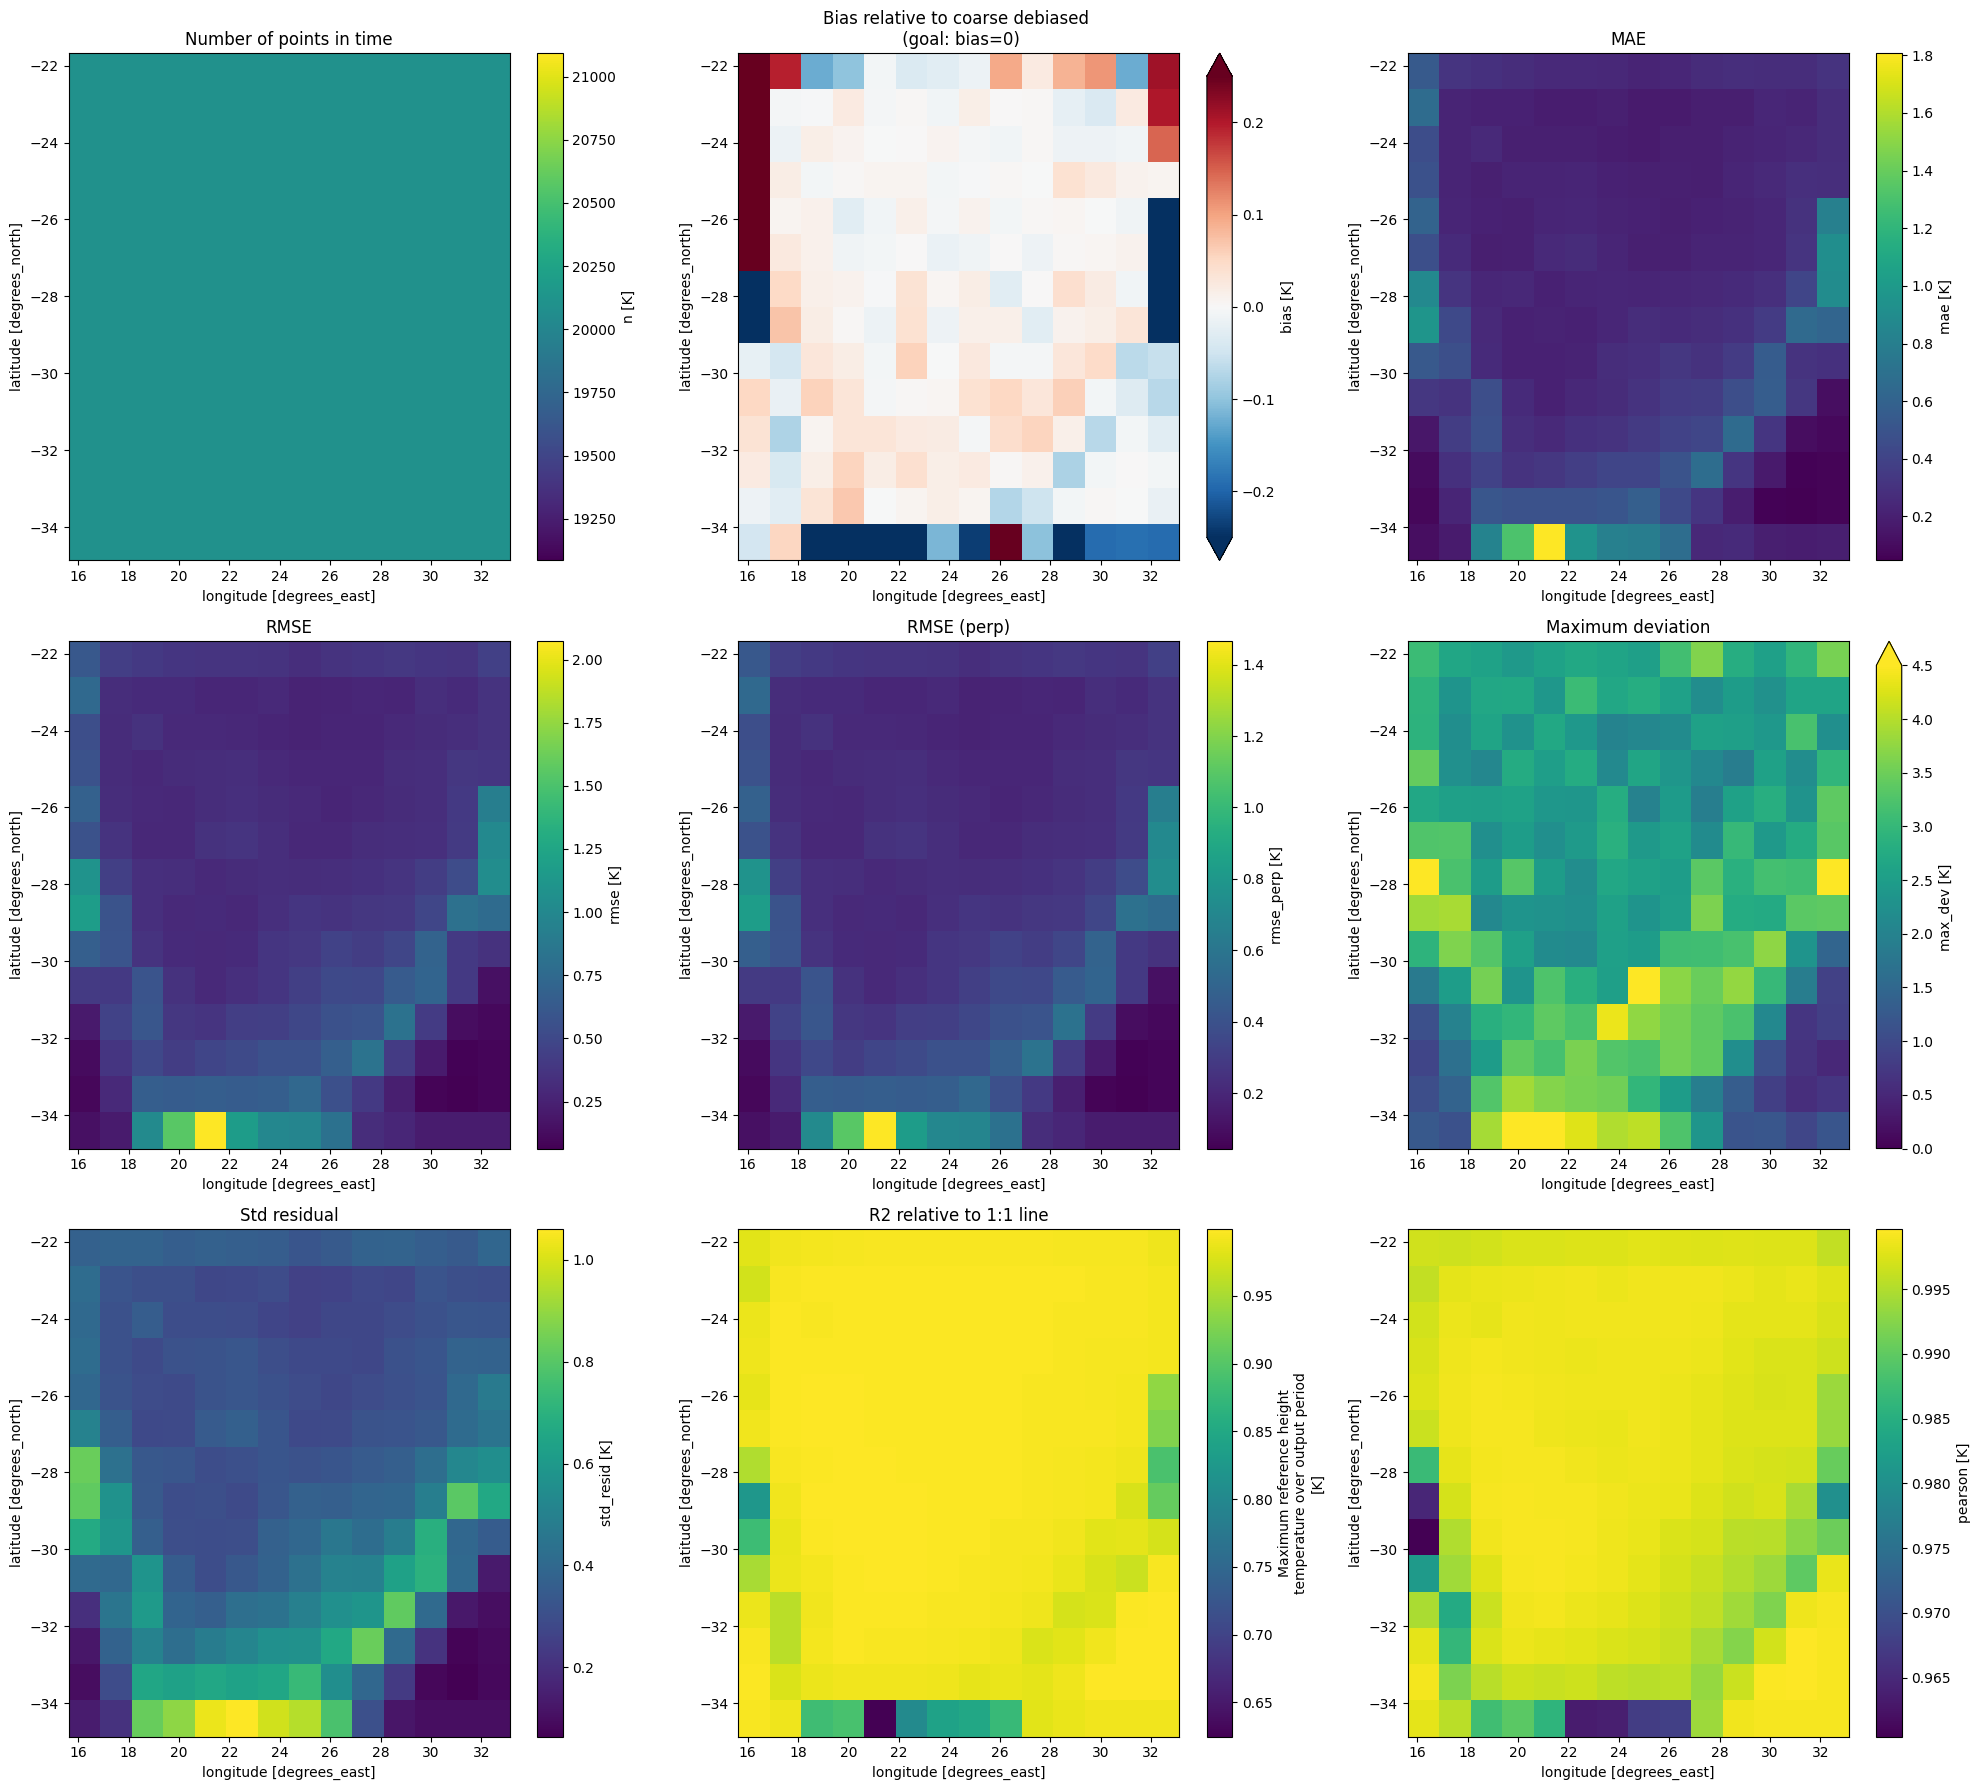

In [23]:
plt.figure(figsize=(20, 18))
plt.subplot(3, 3, 1)
metrics["n"].plot()
plt.title("Number of points in time")
plt.subplot(3, 3, 2)
metrics["bias"].plot(vmax=0.25)
plt.title("Bias relative to coarse debiased \n (goal: bias=0)")
plt.subplot(3, 3, 3)
metrics["mae"].plot()
plt.title("MAE")
plt.subplot(3, 3, 4)
metrics["rmse"].plot()
plt.title("RMSE")
plt.subplot(3, 3, 5)
metrics["rmse_perp"].plot()
plt.title("RMSE (perp)")
plt.subplot(3, 3, 6)
metrics["max_dev"].plot(vmin=0, vmax=4.5)
plt.title("Maximum deviation")
plt.subplot(3, 3, 7)
metrics["std_resid"].plot()
plt.title("Std residual")
plt.subplot(3, 3, 8)
metrics["r2_oneone"].plot()
plt.title("R2 relative to 1:1 line")
plt.subplot(3, 3, 9)
metrics["pearson"].plot()
plt.tight_layout()
plt.savefig(path_figs + "disagg_tests_" + var + "_" + scenario + "_" + ens + "_metric_summary.png")